## Environment Setup & Library Imports

In [1]:
# Cell 1: Install Dependencies (if not already installed) & Import Libraries
!pip install transformers -q
!pip install scikit-learn -q
!pip install pandas -q
!pip install matplotlib -q
!pip install seaborn -q

import os
import re
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import BertTokenizer, TFBertModel, logging as hf_logging
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Conv1D, GlobalMaxPooling1D, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

hf_logging.set_verbosity_error()
print("Libraries imported successfully.")


Libraries imported successfully.


## Data Loading & Preprocessing (ISOT Dataset)

In [6]:
# Cell 2: Load and Preprocess the ISOT Dataset
print("--- Loading and Preprocessing ISOT Dataset ---")

# Load CSV files (Ensure True.csv and Fake.csv are in your current working directory)
try:
    fake_df = pd.read_csv('Fake.csv')
    true_df = pd.read_csv('True.csv')
    print("ISOT dataset CSV files loaded successfully.")
except FileNotFoundError:
    print("Error: Could not find 'True.csv' or 'Fake.csv'. Please upload them to your environment.")

# Text cleaning function
def clean_text(text):
    text = re.sub(r'https?://\S+|www\.\S+', '', str(text))  # Remove URLs
    text = re.sub(r'<.*?>', '', text)                 # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)           # Remove non-alphanumeric characters
    text = text.lower()                               # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()          # Remove extra whitespace
    return text

# Address Data Leakage: Strip Reuters wire prefix from real news text
true_df['text'] = true_df['text'].apply(lambda x: x.split(' - ', 1)[-1])

# Assign Labels: 1 for Fake, 0 for Real
fake_df['label'] = 1
true_df['label'] = 0

# Combine, shuffle, and process content
df = pd.concat([fake_df, true_df]).sample(frac=1, random_state=42).reset_index(drop=True)
df['content'] = (df['title'].astype(str) + ' ' + df['text'].astype(str)).apply(clean_text)
df = df[['content', 'label']]

print(f"\nTotal articles in dataset: {len(df)}")
print("Class distribution:\n", df['label'].value_counts())

--- Loading and Preprocessing ISOT Dataset ---
ISOT dataset CSV files loaded successfully.

Total articles in dataset: 44898
Class distribution:
 label
1    23481
0    21417
Name: count, dtype: int64


# Stratified 70/30 Train-Test Split

In [8]:
# Cell 3: Split Dataset (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    df['content'], df['label'], 
    test_size=0.3, 
    random_state=42, 
    stratify=df['label']
)

print(f"--- Data Split Summary ---")
print(f"Training data size (70%): {len(X_train)}")
print(f"Testing data size (30%):  {len(X_test)}")

--- Data Split Summary ---
Training data size (70%): 31428
Testing data size (30%):  13470


# Tokenization via BERT Tokenizer

In [10]:
# Cell 4: Tokenize Text for BERT
MAX_LEN = 128
MODEL_NAME = 'bert-base-uncased'

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_data(texts, tokenizer, max_len):
    return tokenizer(
        text=texts.tolist(),
        add_special_tokens=True,
        max_length=max_len,
        truncation=True,
        padding='max_length',
        return_tensors='tf'
    )

print("Tokenizing datasets...")
X_train_token = tokenize_data(X_train, tokenizer, MAX_LEN)
X_test_token = tokenize_data(X_test, tokenizer, MAX_LEN)
print("Tokenization complete.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\andre\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\andre\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Tokenizing datasets...
Tokenization complete.


# BERT-CNN Architecture Definition

In [16]:
# Cell 5: Define the BERT-CNN Model (Fixed with use_safetensors=False)
class BertFeatureExtractor(Layer):
    def __init__(self, model_name='bert-base-uncased', **kwargs):
        super(BertFeatureExtractor, self).__init__(**kwargs)
        self.model_name = model_name
        # Added use_safetensors=False to bypass the safetensors environment bug
        self.bert = TFBertModel.from_pretrained(self.model_name, use_safetensors=False)
        self.bert.trainable = False

    def call(self, inputs):
        return self.bert(inputs).last_hidden_state

def create_bert_cnn_model(max_len=MAX_LEN):
    input_ids = Input(shape=(max_len,), dtype=tf.int32, name="input_ids")
    attention_mask = Input(shape=(max_len,), dtype=tf.int32, name="attention_mask")

    bert_extractor = BertFeatureExtractor()
    bert_output = bert_extractor({'input_ids': input_ids, 'attention_mask': attention_mask})

    # CNN Classification Head
    cnn_layer = Conv1D(filters=64, kernel_size=3, padding="valid", activation="relu")(bert_output)
    pooling_layer = GlobalMaxPooling1D()(cnn_layer)

    x = Dropout(0.6)(pooling_layer)
    x = Dense(32, activation="tanh")(x)
    x = Dropout(0.6)(x)
    output = Dense(1, activation="sigmoid", name="classification")(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=output)
    return model

model = create_bert_cnn_model()
model.summary()

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tf_model.h5:   0%|          | 0.00/536M [00:00<?, ?B/s]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ attention_mask (InputLayer)   │ (None, 128)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_ids (InputLayer)        │ (None, 128)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_feature_extractor_2      │ (None, 128, 768)          │               0 │ attention_mask[0][0],      │
│ (BertFeatureExtractor)        │                           │                 │ input_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 126, 64)           │         147,520 │ bert_feature_extractor_2[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 64)                │               0 │ conv1d[0][0]               │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ global_max_pooling1d[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │           2,080 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 32)                │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classification (Dense)        │ (None, 1)                 │              33 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 149,633 (584.50 KB)

 Trainable params: 149,633 (584.50 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training with Callbacks

In [18]:
# Cell 6: Compile and Train the Model
optimizer = Adam(learning_rate=2e-5, epsilon=1e-08)
early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=1, verbose=1, min_lr=1e-7)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Starting model training...")
history = model.fit(
    x={'input_ids': X_train_token['input_ids'], 'attention_mask': X_train_token['attention_mask']},
    y=y_train,
    validation_split=0.1,  # Uses 10% of training data for validation monitoring
    epochs=5,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]
)

Starting model training...
Epoch 1/5
884/884 ━━━━━━━━━━━━━━━━━━━━ 1134s 1s/step - accuracy: 0.5559 - loss: 0.8476 - val_accuracy: 0.8737 - val_loss: 0.4321 - learning_rate: 2.0000e-05
Epoch 2/5
884/884 ━━━━━━━━━━━━━━━━━━━━ 1112s 1s/step - accuracy: 0.6940 - loss: 0.5928 - val_accuracy: 0.9249 - val_loss: 0.2436 - learning_rate: 2.0000e-05
Epoch 3/5
884/884 ━━━━━━━━━━━━━━━━━━━━ 1111s 1s/step - accuracy: 0.8339 - loss: 0.3856 - val_accuracy: 0.9373 - val_loss: 0.1882 - learning_rate: 2.0000e-05
Epoch 4/5
884/884 ━━━━━━━━━━━━━━━━━━━━ 1081s 1s/step - accuracy: 0.8971 - loss: 0.2855 - val_accuracy: 0.9520 - val_loss: 0.1526 - learning_rate: 2.0000e-05
Epoch 5/5
884/884 ━━━━━━━━━━━━━━━━━━━━ 1092s 1s/step - accuracy: 0.9243 - loss: 0.2319 - val_accuracy: 0.9574 - val_loss: 0.1274 - learning_rate: 2.0000e-05
Restoring model weights from the end of the best epoch: 5.


# Evaluation on the 30% Test Set & Visualization


--- Evaluating Model on 30% Test Set ---
421/421 ━━━━━━━━━━━━━━━━━━━━ 478s 1s/step

Classification Report:
              precision    recall  f1-score   support

    Real (0)       0.97      0.95      0.96      6425
    Fake (1)       0.96      0.97      0.96      7045

    accuracy                           0.96     13470
   macro avg       0.96      0.96      0.96     13470
weighted avg       0.96      0.96      0.96     13470


Confusion Matrix:


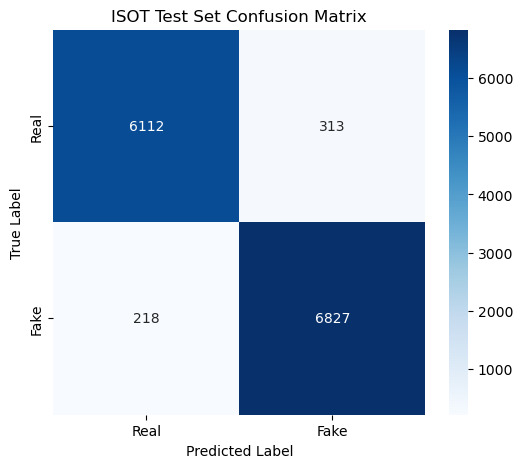

In [20]:
# Cell 7: Evaluate on Test Set and Plot Confusion Matrix
print("\n--- Evaluating Model on 30% Test Set ---")
probs = model.predict({
    'input_ids': X_test_token['input_ids'],
    'attention_mask': X_test_token['attention_mask']
}, batch_size=32).flatten()

preds = (probs >= 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, preds, target_names=['Real (0)', 'Fake (1)']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ISOT Test Set Confusion Matrix")
plt.show()

In [22]:
# Save Model Artifacts to Local Directory
import json
from pathlib import Path

# 1. Define local target directory
output_dir = Path("./isot_fake_news_bert_cnn")
output_dir.mkdir(parents=True, exist_ok=True)
print(f"\nArtifacts will be saved locally to: {output_dir.resolve()}")

# 2. Save model weights (.weights.h5 format)
weights_path = output_dir / "model.weights.h5"
model.save_weights(str(weights_path))
print(f" Model weights saved successfully to: {weights_path}")

# 3. Save the tokenizer
tokenizer_path = output_dir / "tokenizer"
tokenizer.save_pretrained(str(tokenizer_path))
print(f" Tokenizer saved successfully to: {tokenizer_path}")

# 4. Save the configuration file
config = {
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "threshold": 0.5
}
config_path = output_dir / "config.json"
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f" Model configuration saved successfully to: {config_path}")

print("\n All artifacts saved successfully to your local project folder!")


Artifacts will be saved locally to: C:\Users\andre\Documents\Business Analytics\Machine Learning assignment\isot_fake_news_bert_cnn
 Model weights saved successfully to: isot_fake_news_bert_cnn\model.weights.h5
 Tokenizer saved successfully to: isot_fake_news_bert_cnn\tokenizer
 Model configuration saved successfully to: isot_fake_news_bert_cnn\config.json

 All artifacts saved successfully to your local project folder!
